# 07. Latent Space 시각화

VAE 잠재 공간(128차원)을 2D로 축소해 이미지 분포를 시각화합니다.

| 방법 | 특성 |
|------|------|
| PCA | 선형 축소 — 빠르고 전체 분산 파악에 적합 |
| t-SNE | 비선형 — 클러스터 구조 파악에 적합, 느림 |
| UMAP | 비선형 — t-SNE보다 빠르고 전역 구조 보존 (선택) |

## 1. 환경 설정

In [1]:
import os, json, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# fix working directory
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: mps


## 2. 모델 로드

In [2]:
CKPT_DIR = Path('checkpoints_pt')

with open(CKPT_DIR / 'config.json') as f:
    CFG = json.load(f)

LATENT_DIM = CFG['latent_dim']
BASE_CH    = CFG['base_channels']
CHANNELS   = CFG['channels']


class Encoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1),
                       nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv     = nn.Sequential(*layers)
        self.flat_dim = (base_ch * 8) * 4 * 4
        self.fc_mu    = nn.Linear(self.flat_dim, latent_dim)
        self.fc_lv    = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class Decoder(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, self.start_ch, 4, 4))


class VAE(nn.Module):
    def __init__(self, channels=4, base_ch=32, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(channels, base_ch, latent_dim)
        self.decoder = Decoder(channels, base_ch, latent_dim)

    def forward(self, x):
        mu, lv = self.encoder(x)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z), mu, lv


model = VAE(CHANNELS, BASE_CH, LATENT_DIM).to(DEVICE)
model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
model.eval()
print('Model loaded.')

모델 로드 완료.


## 3. 잠재 벡터 수집

In [3]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

# number of samples — more is more accurate but t-SNE gets slower
N_SAMPLES = 1000

random.seed(42)
sample_paths = random.sample(list(all_paths), min(N_SAMPLES, len(all_paths)))

to_tensor = transforms.ToTensor()

@torch.no_grad()
def encode_paths(paths, batch_size=128):
    mu_list = []
    for i in range(0, len(paths), batch_size):
        batch = torch.stack([
            to_tensor(Image.open(p).convert('RGBA')) for p in paths[i:i+batch_size]
        ]).to(DEVICE)
        mu, _ = model.encoder(batch)
        mu_list.append(mu.cpu().numpy())
    return np.concatenate(mu_list)

print(f'Encoding... ({len(sample_paths):,} images)')
Z = encode_paths(sample_paths)
print(f'Latent vector shape: {Z.shape}')

인코딩 중... (1,000장)
잠재 벡터 shape: (1000, 128)


## 4. 레이블 추출 — 파일명 키워드

In [4]:
# label group definitions
# dict key = legend name, value = filename keyword
# first match wins when multiple keywords apply

CHAR_LABELS = {
    'male'     : 'male',
    'female'   : 'female',
    'teen'     : 'teen',
    'child'    : 'child',
    'pregnant' : 'pregnant',
    'muscular' : 'muscular',
}

ACTION_LABELS = {
    'idle'     : 'idle',
    'walk'     : 'walk',
    'run'      : 'run',
    'slash'    : 'slash',
    'shoot'    : 'shoot',
    'thrust'   : 'thrust',
    'jump'     : 'jump',
    'sit'      : 'sit',
    'spellcast': 'spellcast',
}


def assign_labels(paths, label_map):
    labels = []
    for p in paths:
        name = p.name
        matched = 'other'
        for label, kw in label_map.items():
            if kw in name:
                matched = label; break
        labels.append(matched)
    return labels


char_labels   = assign_labels(sample_paths, CHAR_LABELS)
action_labels = assign_labels(sample_paths, ACTION_LABELS)

from collections import Counter
print('Character type distribution:', dict(Counter(char_labels).most_common()))
print('Action distribution:', dict(Counter(action_labels).most_common()))

캐릭터 타입 분포: {'male': 402, 'teen': 201, 'pregnant': 167, 'muscular': 140, 'child': 90}
동작 분포:       {'slash': 217, 'walk': 183, 'shoot': 104, 'jump': 92, 'thrust': 76, 'sit': 70, 'run': 70, 'other': 66, 'spellcast': 62, 'idle': 60}


## 5. PCA 시각화

PCA 설명 분산: PC1=10.09%  PC2=9.46%


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2478834801.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique))


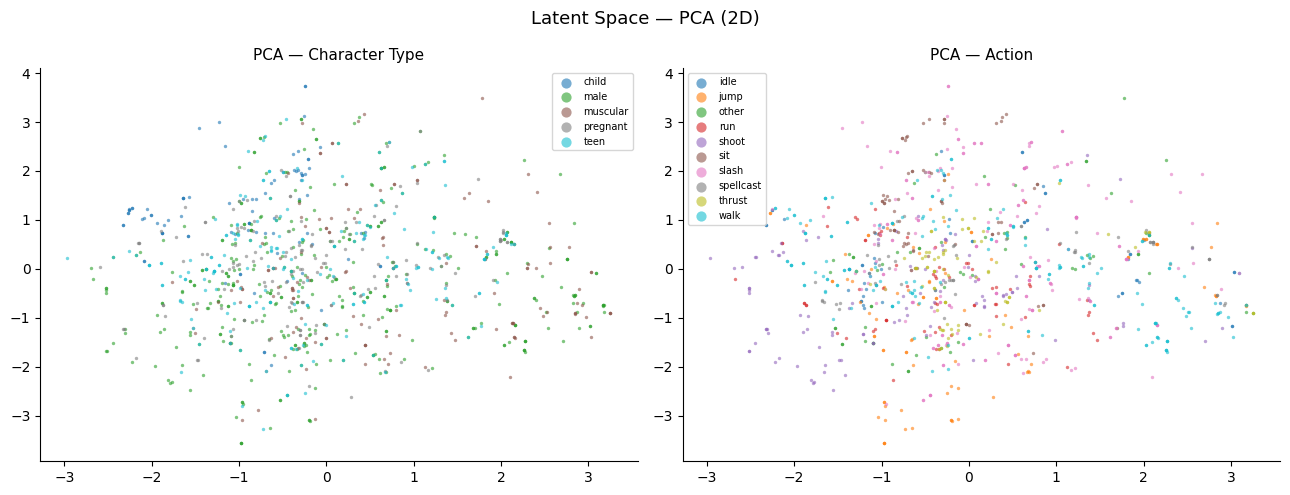

In [5]:
pca   = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(Z)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}  PC2={pca.explained_variance_ratio_[1]:.2%}')


def scatter_plot(Z_2d, labels, title, ax, cmap='tab10'):
    unique = sorted(set(labels))
    colors = plt.cm.get_cmap(cmap, len(unique))
    for i, lbl in enumerate(unique):
        mask = np.array(labels) == lbl
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   c=[colors(i)], label=lbl, s=6, alpha=0.6, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=3, fontsize=7, loc='best')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_pca, char_labels,   'PCA — Character Type', axes[0])
scatter_plot(Z_pca, action_labels, 'PCA — Action',         axes[1])
plt.suptitle('Latent Space — PCA (2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. t-SNE 시각화

t-SNE 실행 중...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.079s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 1.889558
[t-SNE] KL divergence after 50 iterations with early exaggeration: 66.490875
[t-SNE] KL divergence after 1000 iterations: 0.770601
완료.


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2478834801.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique))


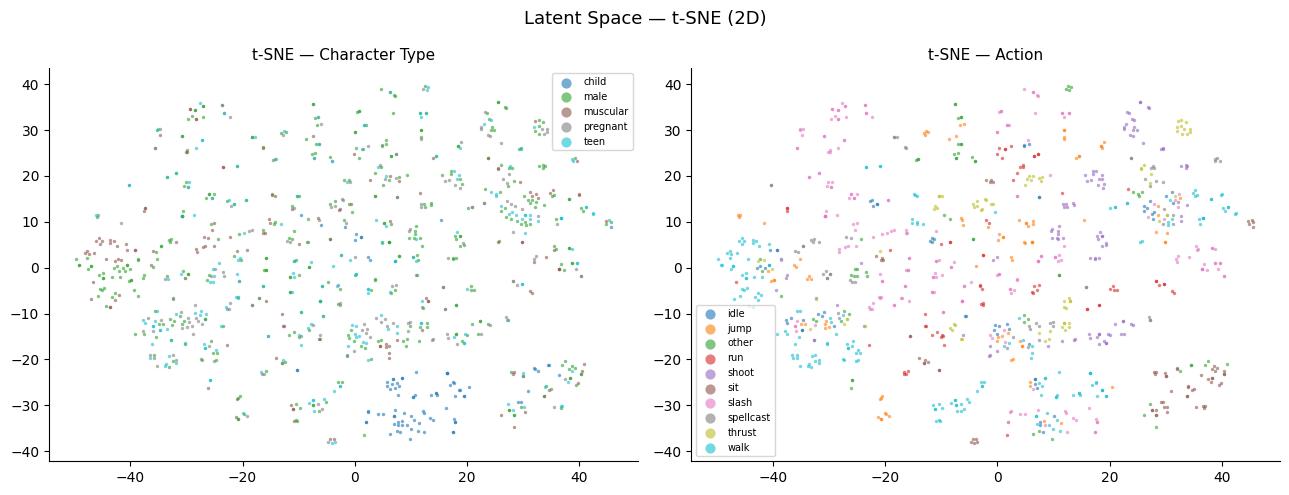

In [7]:
# reduce to 50D with PCA first, then apply t-SNE (speed + quality)
Z_pca50 = PCA(n_components=min(50, Z.shape[1]), random_state=42).fit_transform(Z)

print('Running t-SNE...')
tsne   = TSNE(n_components=2, perplexity=40, random_state=42, verbose=1)
Z_tsne = tsne.fit_transform(Z_pca50)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_tsne, char_labels,   't-SNE — Character Type', axes[0])
scatter_plot(Z_tsne, action_labels, 't-SNE — Action',         axes[1])
plt.suptitle('Latent Space — t-SNE (2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. idle vs 동작 포즈 분포 비교

arithmetic 실험에서 idle이 smoothing 역할을 한 이유를 시각적으로 확인합니다.

      idle: n=  60  평균 std=0.1292
      walk: n= 183  평균 std=0.1446
       run: n=  70  평균 std=0.1627


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2478834801.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique))
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2323875518.py:16: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2323875518.py:16: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2323875518.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_74048/2323875518.py:16: 

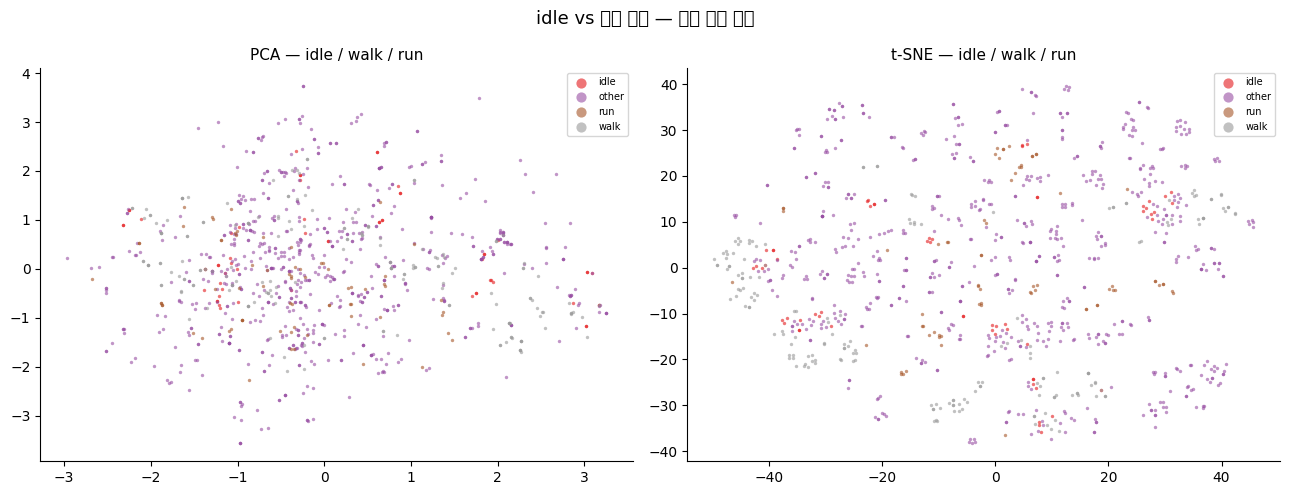

In [8]:
# compare only idle / walk / run
focus_map   = {'idle': 'idle', 'walk': 'walk', 'run': 'run'}
focus_labels = assign_labels(sample_paths, focus_map)

# print per-group latent vector std
for lbl in ['idle', 'walk', 'run']:
    mask = np.array(action_labels) == lbl
    if mask.sum() == 0: continue
    std = Z[mask].std(axis=0).mean()
    print(f'{lbl:>10}: n={mask.sum():>4}  mean std={std:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter_plot(Z_pca,  focus_labels, 'PCA — idle / walk / run',   axes[0], cmap='Set1')
scatter_plot(Z_tsne, focus_labels, 't-SNE — idle / walk / run', axes[1], cmap='Set1')
plt.suptitle('idle vs Action Poses — Latent Space Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## 8. UMAP 시각화 (선택)

In [ ]:
# requires umap-learn: pip install umap-learn
try:
    import umap
    print('Running UMAP...')
    reducer = umap.UMAP(n_components=2, random_state=42)
    Z_umap  = reducer.fit_transform(Z)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    scatter_plot(Z_umap, char_labels,   'UMAP — Character Type', axes[0])
    scatter_plot(Z_umap, action_labels, 'UMAP — Action',         axes[1])
    plt.suptitle('Latent Space — UMAP (2D)', fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('umap-learn not installed — run: pip install umap-learn')

## 9. 잠재 벡터 통계 요약

In [ ]:
print(f'{'group':>12}  {'n':>5}  {'μ mean':>10}  {'μ std':>10}')
print('-' * 45)
for lbl, kw in {**CHAR_LABELS, **ACTION_LABELS}.items():
    mask = np.array(action_labels if lbl in ACTION_LABELS else char_labels) == lbl
    if mask.sum() == 0: continue
    g = Z[mask]
    print(f'{lbl:>12}  {mask.sum():>5}  {g.mean():>10.4f}  {g.std():>10.4f}')

# check how close the overall distribution is to prior N(0,1)
print(f'\nAll  mean={Z.mean():.4f}  std={Z.std():.4f}  (ideal: mean=0, std=1)')